# EDA: Rosbank Churn Prediction
DME-Encoder project — exploratory data analysis for the rosbank dataset.

In [1]:
# Cell 1 — README и описание датасета
from pathlib import Path
from IPython.display import Markdown, display

readme_path = Path("../data/raw/rosbank/README.md")
readme_text = readme_path.read_text()
display(Markdown(readme_text))
print(readme_text)

---
pretty_name: Rosbank churn prediction competition
task_categories:
- tabular-classification
tags:
- finance
configs:
  - config_name: train
    data_files: train.csv.gz
  - config_name: test
    data_files: test.csv.gz
---

https://boosters.pro/championship/rosbank1/

---
pretty_name: Rosbank churn prediction competition
task_categories:
- tabular-classification
tags:
- finance
configs:
  - config_name: train
    data_files: train.csv.gz
  - config_name: test
    data_files: test.csv.gz
---

https://boosters.pro/championship/rosbank1/


In [2]:
# Cell 2 — Загрузка данных
import pandas as pd
import numpy as np

ENTITY_COL    = "cl_id"
TIMESTAMP_COL = "TRDATETIME"
EVENT_TYPE_COL = "MCC"
TARGET_COL    = "target_flag"
NUM_COLS      = ["amount"]
CAT_COLS      = ["channel_type", "trx_category", "currency"]

# Загрузка
train = pd.read_csv("../data/raw/rosbank/train.csv.gz")
test  = pd.read_csv("../data/raw/rosbank/test.csv.gz")

# Парсинг временной метки: формат "21OCT17:00:00:00"
for df in [train, test]:
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], format="%d%b%y:%H:%M:%S")

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print("\nDtypes:")
print(train.dtypes)
print("\nHead(5):")
display(train.head(5))
print("\nDescribe:")
display(train.describe(include="all"))

print("\n=== TEST ===")
print(f"Shape: {test.shape}")
print("\nDtypes:")
print(test.dtypes)
print("\nHead(5):")
display(test.head(5))
print("\nDescribe:")
display(test.describe(include="all"))

# Таблица маппинга
role_map = [
    ("cl_id",        "entity_id",        train["cl_id"].dtype),
    ("TRDATETIME",   "timestamp",        train["TRDATETIME"].dtype),
    ("MCC",          "event_type",       train["MCC"].dtype),
    ("target_flag",  "target",           train["target_flag"].dtype),
    ("amount",       "numerical",        train["amount"].dtype),
    ("channel_type", "categorical",      train["channel_type"].dtype),
    ("trx_category", "categorical",      train["trx_category"].dtype),
    ("currency",     "categorical",      train["currency"].dtype),
    ("PERIOD",       "period (aux)",     train["PERIOD"].dtype),
    ("target_sum",   "target_sum (aux)", train["target_sum"].dtype),
]
role_df = pd.DataFrame(role_map, columns=["column", "role", "dtype"])
print("\n=== Маппинг колонок ===")
display(role_df)

=== TRAIN ===
Shape: (490513, 10)

Dtypes:
PERIOD                  object
cl_id                    int64
MCC                      int64
channel_type            object
currency                 int64
TRDATETIME      datetime64[ns]
amount                 float64
trx_category            object
target_flag              int64
target_sum             float64
dtype: object

Head(5):


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
0,01/10/2017,0,5200,NaN,810,2017-10-21 00:00:00,5023.0,POS,0,0.0
1,01/10/2017,0,6011,NaN,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0
2,01/12/2017,0,5921,NaN,810,2017-12-05 00:00:00,767.0,POS,0,0.0
3,01/10/2017,0,5411,NaN,810,2017-10-21 00:00:00,2031.0,POS,0,0.0
4,01/10/2017,0,6012,NaN,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0



Describe:


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
count,490513,490513.000000,490513.000000,487603,490513.000000,490513,4.905130e+05,490513,490513.000000,4.905130e+05
unique,19,NaN,NaN,5,NaN,NaN,NaN,10,NaN,NaN
top,01/07/2017,NaN,NaN,type1,NaN,NaN,NaN,POS,NaN,NaN
freq,55757,NaN,NaN,299247,NaN,NaN,NaN,416425,NaN,NaN
mean,NaN,4802.127361,5699.783822,NaN,810.601854,2017-05-06 07:49:19.149182720,5.723594e+03,NaN,0.652588,1.627345e+05
min,NaN,0.000000,742.000000,NaN,32.000000,2016-10-07 00:00:00,4.000000e-02,NaN,0.000000,0.000000e+00
25%,NaN,2193.000000,5411.000000,NaN,810.000000,2017-02-07 00:00:00,2.240000e+02,NaN,0.000000,0.000000e+00
50%,NaN,4576.000000,5661.000000,NaN,810.000000,2017-05-11 00:00:00,6.240000e+02,NaN,1.000000,2.491009e+04
75%,NaN,7390.000000,5941.000000,NaN,810.000000,2017-07-21 00:00:00,2.176000e+03,NaN,1.000000,1.516193e+05
max,NaN,10215.000000,9405.000000,NaN,986.000000,2018-04-02 23:20:35,3.583500e+07,NaN,1.000000,4.606578e+07



=== TEST ===
Shape: (518376, 8)

Dtypes:
PERIOD                  object
cl_id                    int64
MCC                      int64
channel_type            object
currency                 int64
TRDATETIME      datetime64[ns]
amount                 float64
trx_category            object
dtype: object

Head(5):


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category
0,01/04/2017,2,5814,NaN,810,2017-04-18,153.00,POS
1,01/03/2017,2,5812,NaN,810,2017-03-10,388.08,POS
2,01/02/2017,2,5691,NaN,810,2017-02-21,999.00,POS
3,01/04/2017,2,5814,NaN,810,2017-04-26,90.00,POS
4,01/04/2017,2,5814,NaN,810,2017-04-08,130.00,POS



Describe:


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category
count,518376,518376.000000,518376.000000,516222,518376.000000,518376,5.183760e+05,518376
unique,19,NaN,NaN,5,NaN,NaN,NaN,10
top,01/07/2017,NaN,NaN,type1,NaN,NaN,NaN,POS
freq,58598,NaN,NaN,320509,NaN,NaN,NaN,442149
mean,NaN,4783.074162,5691.949272,NaN,810.661423,2017-05-02 10:54:06.548152064,5.510122e+03,NaN
min,NaN,2.000000,742.000000,NaN,32.000000,2016-10-07 00:00:00,1.000000e-02,NaN
25%,NaN,2181.000000,5411.000000,NaN,810.000000,2017-02-02 00:00:00,2.180000e+02,NaN
50%,NaN,4591.000000,5655.000000,NaN,810.000000,2017-05-06 00:00:00,6.090000e+02,NaN
75%,NaN,7304.000000,5921.000000,NaN,810.000000,2017-07-18 00:00:00,2.113000e+03,NaN
max,NaN,10216.000000,9405.000000,NaN,986.000000,2018-04-02 19:52:13,1.825285e+07,NaN



=== Маппинг колонок ===


,column,role,dtype
0,cl_id,entity_id,int64
1,TRDATETIME,timestamp,datetime64[ns]
2,MCC,event_type,int64
3,target_flag,target,int64
4,amount,numerical,float64
5,channel_type,categorical,object
6,trx_category,categorical,object
7,currency,categorical,int64
8,PERIOD,period (aux),object
9,target_sum,target_sum (aux),float64


Уникальных клиентов в train: 5,000
Уникальных клиентов в test:  5,217

Распределение кол-ва транзакций на клиента:
mean       98.1
median     83.0
p75       145.0
p90       203.0
p95       243.0
p99       331.0
max       784.0

Клиентов с < 5 транзакций:   157 (3.1%)
Клиентов с > 500 транзакций: 3 (0.1%)

Рекомендуемый max_seq_len (p95): 243


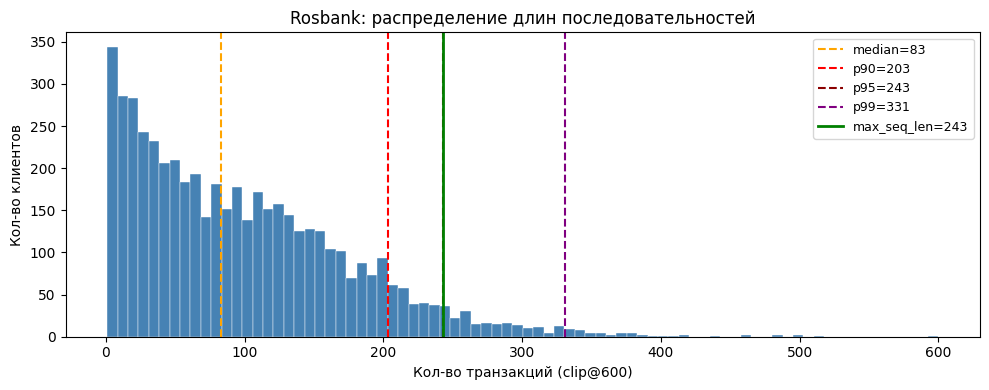

Сохранено: outputs/figures/eda/rosbank_seq_length.png


In [3]:
# Cell 3 — Статистика по клиентам
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures/eda", exist_ok=True)

train_clients = train[ENTITY_COL].nunique()
test_clients  = test[ENTITY_COL].nunique()
print(f"Уникальных клиентов в train: {train_clients:,}")
print(f"Уникальных клиентов в test:  {test_clients:,}")

txn_counts = train.groupby(ENTITY_COL).size()
percentiles = txn_counts.quantile([0.50, 0.75, 0.90, 0.95, 0.99])

print("\nРаспределение кол-ва транзакций на клиента:")
stats = pd.Series({
    "mean":   txn_counts.mean(),
    "median": txn_counts.median(),
    "p75":    percentiles[0.75],
    "p90":    percentiles[0.90],
    "p95":    percentiles[0.95],
    "p99":    percentiles[0.99],
    "max":    txn_counts.max(),
})
print(stats.round(1).to_string())

lt5   = (txn_counts < 5).sum()
gt500 = (txn_counts > 500).sum()
print(f"\nКлиентов с < 5 транзакций:   {lt5:,} ({100*lt5/train_clients:.1f}%)")
print(f"Клиентов с > 500 транзакций: {gt500:,} ({100*gt500/train_clients:.1f}%)")

recommended_max = int(percentiles[0.95])
print(f"\nРекомендуемый max_seq_len (p95): {recommended_max}")

# График
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(txn_counts.clip(upper=600), bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
colors = {"median": "orange", "p90": "red", "p95": "darkred", "p99": "purple"}
for label, pct in [("median", 0.50), ("p90", 0.90), ("p95", 0.95), ("p99", 0.99)]:
    v = percentiles[pct]
    ax.axvline(v, color=colors[label], linestyle="--", linewidth=1.5, label=f"{label}={v:.0f}")
ax.axvline(recommended_max, color="green", linestyle="-", linewidth=2,
           label=f"max_seq_len={recommended_max}")
ax.set_xlabel("Кол-во транзакций (clip@600)")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Rosbank: распределение длин последовательностей")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/rosbank_seq_length.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/rosbank_seq_length.png")

Распределение target_flag (по клиентам):


,count,%
target_flag,,
0,2233,44.66
1,2767,55.34



Коэффициент дисбаланса (majority/minority): 1.24
Рекомендация: class_weights не нужны (дисбаланс умеренный)


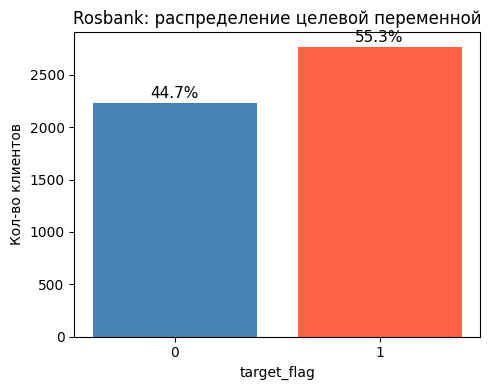

Сохранено: outputs/figures/eda/rosbank_target.png


In [4]:
# Cell 4 — Целевая переменная
target_counts = train.groupby(ENTITY_COL)[TARGET_COL].first()
vc = target_counts.value_counts().sort_index()
vc_pct = vc / vc.sum() * 100

print("Распределение target_flag (по клиентам):")
tdf = pd.DataFrame({"count": vc, "%": vc_pct.round(2)})
display(tdf)

imbalance_ratio = vc.max() / vc.min()
print(f"\nКоэффициент дисбаланса (majority/minority): {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    minority_weight = round(vc.max() / vc.min(), 2)
    print(f"Рекомендация: использовать class_weights = {{0: 1.0, 1: {minority_weight}}}")
else:
    print("Рекомендация: class_weights не нужны (дисбаланс умеренный)")

# График
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar([str(k) for k in vc.index], vc.values, color=["steelblue", "tomato"])
for bar, pct in zip(bars, vc_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=11)
ax.set_xlabel("target_flag")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Rosbank: распределение целевой переменной")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/rosbank_target.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/rosbank_target.png")

Уникальных значений MCC: 344

Топ-30 MCC:


,count,%
MCC,,
5411,121640,24.799
6011,54382,11.087
5814,41351,8.430
5812,30027,6.122
5499,27237,5.553
5541,19816,4.040
5912,18728,3.818
5999,13073,2.665
6012,10056,2.050



Редких MCC (count < 5):  90
Редких MCC (count < 10): 125
Доля топ-10 MCC в объёме: 70.3%


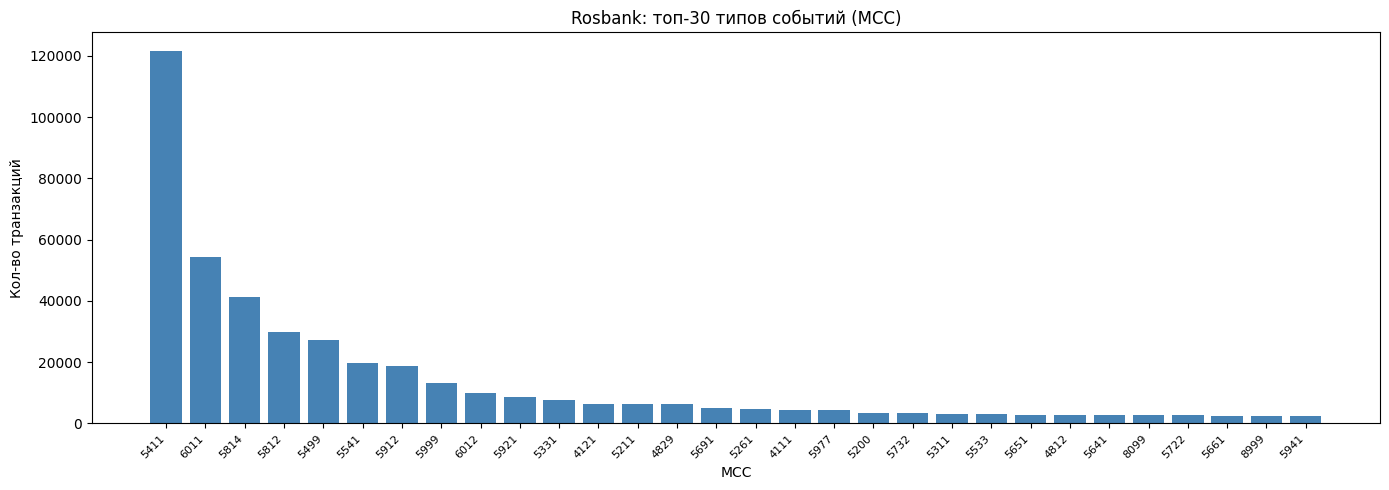

Сохранено: outputs/figures/eda/rosbank_event_types.png


In [5]:
# Cell 5 — Анализ event_type (MCC)
n_unique = train[EVENT_TYPE_COL].nunique()
print(f"Уникальных значений MCC: {n_unique}")

mcc_counts = train[EVENT_TYPE_COL].value_counts()
total_txn  = len(train)

top30 = mcc_counts.head(30)
top30_df = pd.DataFrame({"count": top30, "%": (top30 / total_txn * 100).round(3)})
print("\nТоп-30 MCC:")
display(top30_df)

rare_lt5  = (mcc_counts < 5).sum()
rare_lt10 = (mcc_counts < 10).sum()
top10_share = mcc_counts.head(10).sum() / total_txn * 100
print(f"\nРедких MCC (count < 5):  {rare_lt5}")
print(f"Редких MCC (count < 10): {rare_lt10}")
print(f"Доля топ-10 MCC в объёме: {top10_share:.1f}%")

# График
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top30)), top30.values, color="steelblue")
ax.set_xticks(range(len(top30)))
ax.set_xticklabels([str(x) for x in top30.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("MCC")
ax.set_ylabel("Кол-во транзакций")
ax.set_title("Rosbank: топ-30 типов событий (MCC)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/rosbank_event_types.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/rosbank_event_types.png")

Статистика time_delta (секунды):
mean         71260.6
median           0.0
p75          86400.0
p90         172800.0
p99         878816.6
max       30356581.0

Доля нулевых дельт (одновременные): 51.86%
Доля отрицательных дельт (аномалии): 0.00%

Mean/Median ratio: 71260.6x — heavy tail обнаружен → рекомендуется log1p преобразование
Skewness: 24.63


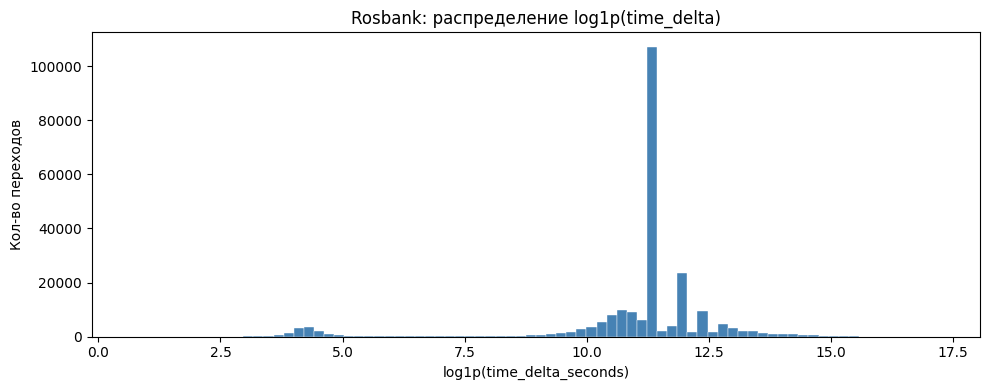

Сохранено: outputs/figures/eda/rosbank_time_delta.png


In [6]:
# Cell 6 — Анализ time_delta
train_sorted = train.sort_values([ENTITY_COL, TIMESTAMP_COL])
time_delta_sec = (
    train_sorted
    .groupby(ENTITY_COL)[TIMESTAMP_COL]
    .diff()
    .dt.total_seconds()
)

td_valid = time_delta_sec.dropna()
pct = td_valid.quantile([0.50, 0.75, 0.90, 0.99])

print("Статистика time_delta (секунды):")
stats_td = pd.Series({
    "mean":   td_valid.mean(),
    "median": td_valid.median(),
    "p75":    pct[0.75],
    "p90":    pct[0.90],
    "p99":    pct[0.99],
    "max":    td_valid.max(),
})
print(stats_td.round(1).to_string())

zero_frac = (td_valid == 0).mean() * 100
neg_frac  = (td_valid < 0).mean() * 100
print(f"\nДоля нулевых дельт (одновременные): {zero_frac:.2f}%")
print(f"Доля отрицательных дельт (аномалии): {neg_frac:.2f}%")

# Heavy tail?
mean_val = td_valid.mean()
median_val = td_valid.median()
skew = td_valid[td_valid >= 0].skew()
print(f"\nMean/Median ratio: {mean_val/max(median_val,1):.1f}x — ", end="")
if mean_val > 3 * median_val:
    print("heavy tail обнаружен → рекомендуется log1p преобразование")
else:
    print("распределение умеренное")
print(f"Skewness: {skew:.2f}")

# График
td_positive = td_valid[td_valid > 0]
log_td = np.log1p(td_positive)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(log_td, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlabel("log1p(time_delta_seconds)")
ax.set_ylabel("Кол-во переходов")
ax.set_title("Rosbank: распределение log1p(time_delta)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/rosbank_time_delta.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/rosbank_time_delta.png")

In [7]:
# Cell 7 — Анализ числовых признаков
print("=== Числовые признаки ===")
rows = []
for col in NUM_COLS:
    s = train[col]
    pct99 = s.quantile(0.99)
    pct_null = s.isna().mean() * 100
    pct_zero = (s == 0).mean() * 100
    pct_neg  = (s < 0).mean() * 100
    skewness = s.dropna().skew()
    # Рекомендация
    if pct_neg > 1:
        rec = "sign*log1p(|x|)"
    elif abs(skewness) > 2:
        rec = "log1p / RobustScaler"
    else:
        rec = "StandardScaler"
    rows.append({
        "column":    col,
        "mean":      round(s.mean(), 3),
        "std":       round(s.std(), 3),
        "min":       round(s.min(), 3),
        "max":       round(s.max(), 3),
        "p99":       round(pct99, 3),
        "% null":    round(pct_null, 2),
        "% zero":    round(pct_zero, 2),
        "% neg":     round(pct_neg, 2),
        "skewness":  round(skewness, 2),
        "recommendation": rec,
    })
display(pd.DataFrame(rows).set_index("column"))

=== Числовые признаки ===


,mean,std,min,max,p99,% null,% zero,% neg,skewness,recommendation
column,,,,,,,,,,
amount,5723.594,77037.634,0.04,35835000.0,98000.0,0.0,0.0,0.0,338.07,log1p / RobustScaler


In [8]:
# Cell 8 — Анализ категориальных признаков
print("=== Категориальные признаки ===")
for col in CAT_COLS:
    s = train[col].astype(str).replace("nan", np.nan)
    n_unique  = train[col].nunique(dropna=True)
    pct_null  = train[col].isna().mean() * 100
    vc        = train[col].value_counts(dropna=True)
    rare      = (vc < 5).sum()
    top5      = vc.head(5)
    print(f"\n--- {col} ---")
    print(f"  n_unique:  {n_unique}")
    print(f"  % null:    {pct_null:.2f}%")
    print(f"  % редких (count<5): {rare} значений ({100*rare/max(n_unique,1):.1f}%)")
    print("  Топ-5 значений:")
    top5_df = pd.DataFrame({"count": top5, "%": (top5/len(train)*100).round(2)})
    display(top5_df)

=== Категориальные признаки ===



--- channel_type ---
  n_unique:  5
  % null:    0.59%
  % редких (count<5): 0 значений (0.0%)
  Топ-5 значений:


,count,%
channel_type,,
type1,299247,61.01
type2,175013,35.68
type5,5587,1.14
type4,4476,0.91
type3,3280,0.67



--- trx_category ---
  n_unique:  10
  % null:    0.00%
  % редких (count<5): 0 значений (0.0%)
  Топ-5 значений:


,count,%
trx_category,,
POS,416425,84.90
DEPOSIT,21216,4.33
WD_ATM_ROS,19104,3.89
WD_ATM_PARTNER,9948,2.03
C2C_IN,7306,1.49



--- currency ---
  n_unique:  59
  % null:    0.00%
  % редких (count<5): 10 значений (16.9%)
  Топ-5 значений:


,count,%
currency,,
810,477644,97.38
978,5536,1.13
840,1921,0.39
933,561,0.11
985,423,0.09


Топ-15 переходов (from → to):


,from,to,count
0,5411,5411,42259
1,6011,6011,20820
2,5814,5814,9648
3,5411,5814,9009
4,5814,5411,9004
5,6011,5411,8755
6,5411,6011,8695
7,5411,5499,6380
8,5499,5411,6368
9,5812,5411,6162



Средняя энтропия строк матрицы переходов (топ-20): 3.28 бит
Максимальная возможная энтропия (равномерная): 4.32 бит
Вывод: переходы относительно равномерны — умеренная структура


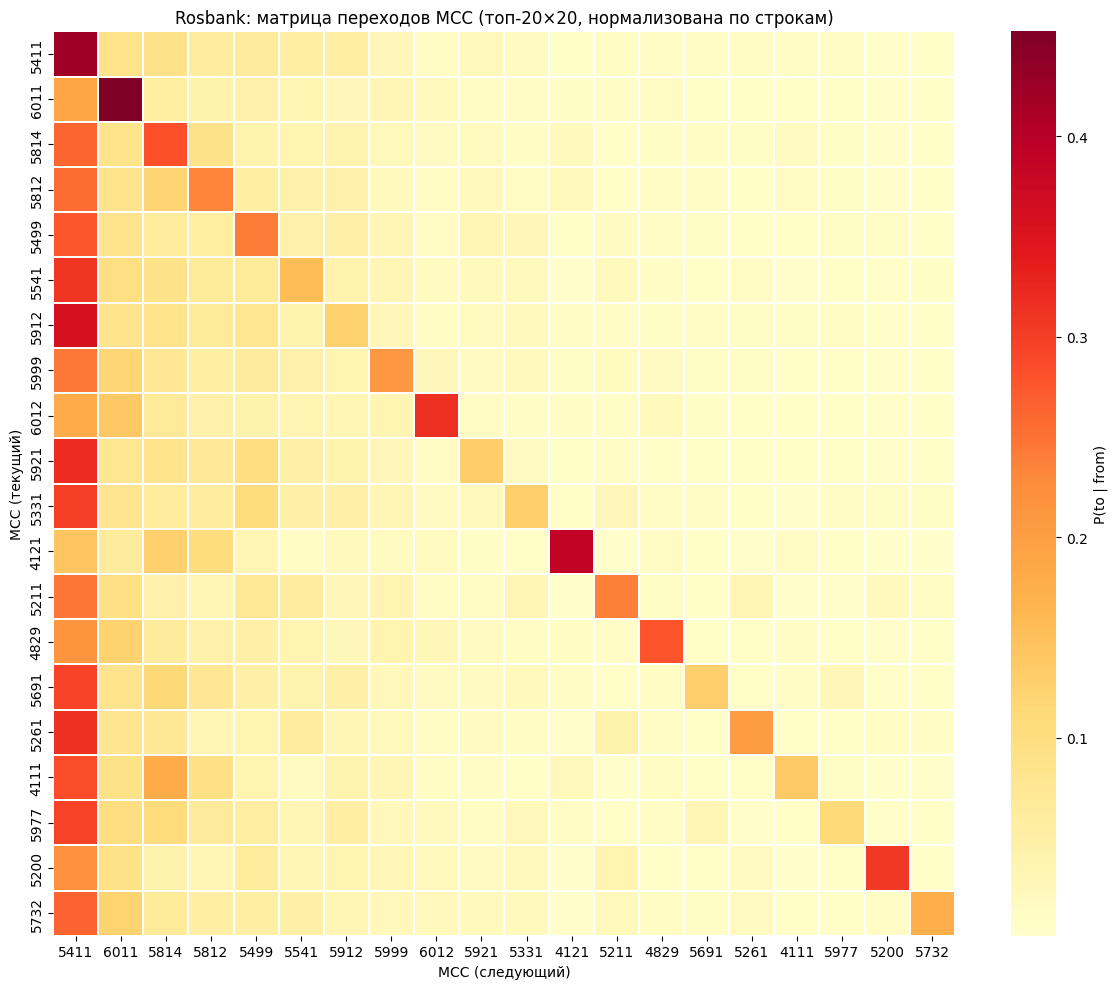

Сохранено: outputs/figures/eda/rosbank_transitions.png


In [9]:
# Cell 9 — Transition matrix
import seaborn as sns
from scipy.stats import entropy
from collections import Counter

train_sorted2 = train.sort_values([ENTITY_COL, TIMESTAMP_COL])

# Строим пары переходов
pairs = []
for _, grp in train_sorted2.groupby(ENTITY_COL)[EVENT_TYPE_COL]:
    seq = grp.tolist()
    pairs.extend(zip(seq[:-1], seq[1:]))

pair_counts = Counter(pairs)
top15_pairs = pair_counts.most_common(15)
print("Топ-15 переходов (from → to):")
top15_df = pd.DataFrame(top15_pairs, columns=["transition", "count"])
top15_df["from"] = top15_df["transition"].apply(lambda x: x[0])
top15_df["to"]   = top15_df["transition"].apply(lambda x: x[1])
display(top15_df[["from", "to", "count"]])

# Топ-20 MCC для heatmap
top20_mcc = train[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat = pd.DataFrame(0, index=top20_mcc, columns=top20_mcc, dtype=float)
for (a, b), cnt in pair_counts.items():
    if a in mat.index and b in mat.columns:
        mat.loc[a, b] += cnt

# Нормализация по строкам
row_sums = mat.sum(axis=1).replace(0, 1)
mat_norm = mat.div(row_sums, axis=0)

# Средняя энтропия строк
row_entropies = mat_norm.apply(lambda row: entropy(row + 1e-12, base=2), axis=1)
mean_entropy = row_entropies.mean()
max_entropy  = np.log2(len(top20_mcc))
print(f"\nСредняя энтропия строк матрицы переходов (топ-20): {mean_entropy:.2f} бит")
print(f"Максимальная возможная энтропия (равномерная): {max_entropy:.2f} бит")
if mean_entropy < 0.5 * max_entropy:
    print("Вывод: переходы СТРУКТУРИРОВАНЫ — transition-aware replacement полезен")
else:
    print("Вывод: переходы относительно равномерны — умеренная структура")

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    mat_norm,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.3,
    cbar_kws={"label": "P(to | from)"},
    xticklabels=[str(x) for x in top20_mcc],
    yticklabels=[str(x) for x in top20_mcc],
)
ax.set_xlabel("MCC (следующий)")
ax.set_ylabel("MCC (текущий)")
ax.set_title("Rosbank: матрица переходов MCC (топ-20×20, нормализована по строкам)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/rosbank_transitions.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/rosbank_transitions.png")

In [10]:
# Cell 10 — Проверка качества данных
print("=== Проверка качества ===")

# Дубликаты (cl_id, TRDATETIME)
dup_train = train.duplicated(subset=[ENTITY_COL, TIMESTAMP_COL]).sum()
print(f"Дубликаты (cl_id, TRDATETIME) в train: {dup_train:,}")

# Клиенты с 1 транзакцией
singleton_clients = (train.groupby(ENTITY_COL).size() == 1).sum()
print(f"Клиентов с ровно 1 транзакцией: {singleton_clients:,}")

# Пропуски в ключевых полях
key_cols = [ENTITY_COL, TIMESTAMP_COL, EVENT_TYPE_COL]
print("\nПропуски в ключевых полях (train):")
for col in key_cols:
    n_null = train[col].isna().sum()
    print(f"  {col}: {n_null:,} ({100*n_null/len(train):.3f}%)")

# Временные аномалии
ts = train[TIMESTAMP_COL]
before_2000 = (ts.dt.year < 2000).sum()
future       = (ts.dt.year > 2026).sum()
print(f"\nТранзакции до 2000 года: {before_2000:,}")
print(f"Транзакции после 2026:   {future:,}")
print(f"Диапазон дат train: {ts.min()} — {ts.max()}")

# Пересечение cl_id между train и test
train_ids = set(train[ENTITY_COL].unique())
test_ids  = set(test[ENTITY_COL].unique())
overlap   = train_ids & test_ids
print(f"\nПересечение cl_id train∩test: {len(overlap):,} клиентов")
if len(overlap) > 0:
    print("  Внимание: клиенты присутствуют в обоих сплитах")
else:
    print("  OK: train и test не пересекаются")

=== Проверка качества ===
Дубликаты (cl_id, TRDATETIME) в train: 251,769
Клиентов с ровно 1 транзакцией: 34

Пропуски в ключевых полях (train):
  cl_id: 0 (0.000%)
  TRDATETIME: 0 (0.000%)
  MCC: 0 (0.000%)

Транзакции до 2000 года: 0
Транзакции после 2026:   0
Диапазон дат train: 2016-10-07 00:00:00 — 2018-04-02 23:20:35



Пересечение cl_id train∩test: 0 клиентов
  OK: train и test не пересекаются


In [11]:
# Cell 11 — Итоги и сохранение
import json

# Пересобираем ключевые метрики
txn_counts_final = train.groupby(ENTITY_COL).size()
pct_final = txn_counts_final.quantile([0.95, 0.99])
max_seq_len_rec = int(pct_final[0.95])

target_per_client = train.groupby(ENTITY_COL)[TARGET_COL].first()
vc_final = target_per_client.value_counts()
imbalance = float(vc_final.max() / vc_final.min())

vocab_size = train[EVENT_TYPE_COL].nunique()

# Определяем рекомендации
td_vals = train.sort_values([ENTITY_COL, TIMESTAMP_COL]).groupby(ENTITY_COL)[TIMESTAMP_COL].diff().dt.total_seconds().dropna()
use_log1p_time = bool(td_vals[td_vals > 0].mean() > 3 * td_vals[td_vals > 0].median())

amount_skew = train["amount"].skew()
amount_neg_pct = (train["amount"] < 0).mean() * 100
if amount_neg_pct > 1:
    recommended_scaler = "sign*log1p"
elif abs(amount_skew) > 2:
    recommended_scaler = "RobustScaler"
else:
    recommended_scaler = "StandardScaler"

# Transition-aware useful?
td_ent_check = train.sort_values([ENTITY_COL, TIMESTAMP_COL])
pairs_check = []
for _, grp in td_ent_check.groupby(ENTITY_COL)[EVENT_TYPE_COL]:
    seq = grp.tolist()
    pairs_check.extend(zip(seq[:-1], seq[1:]))
pc2 = Counter(pairs_check)
top20_check = train[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat2 = pd.DataFrame(0, index=top20_check, columns=top20_check, dtype=float)
for (a, b), cnt in pc2.items():
    if a in mat2.index and b in mat2.columns:
        mat2.loc[a, b] += cnt
rs2 = mat2.sum(axis=1).replace(0, 1)
mn2 = mat2.div(rs2, axis=0)
mean_ent2 = mn2.apply(lambda r: entropy(r + 1e-12, base=2), axis=1).mean()
transition_aware_useful = bool(mean_ent2 < 0.5 * np.log2(20))

# Таблица рекомендаций
recs = {
    "max_seq_len":             max_seq_len_rec,
    "min_seq_len":             2,
    "vocab_size":              int(vocab_size),
    "class_imbalance_ratio":   round(imbalance, 2),
    "use_log1p_time":          use_log1p_time,
    "recommended_scaler":      recommended_scaler,
    "transition_aware_useful": transition_aware_useful,
    "n_train_clients":         int(train[ENTITY_COL].nunique()),
    "n_test_clients":          int(test[ENTITY_COL].nunique()),
    "n_train_txn":             int(len(train)),
    "n_test_txn":              int(len(test)),
    "mean_seq_len":            round(float(txn_counts_final.mean()), 2),
    "median_seq_len":          int(txn_counts_final.median()),
    "p90_seq_len":             int(txn_counts_final.quantile(0.90)),
    "p95_seq_len":             int(txn_counts_final.quantile(0.95)),
    "p99_seq_len":             int(txn_counts_final.quantile(0.99)),
    "mean_entropy_transitions": round(float(mean_ent2), 4),
}

print("=== Итоговые рекомендации ===")
display(pd.Series(recs).to_frame("value"))

# Сохранение JSON
os.makedirs("../outputs/metrics", exist_ok=True)
out_path = "../outputs/metrics/eda_rosbank.json"
with open(out_path, "w") as f:
    json.dump(recs, f, indent=2)
print(f"\nСохранено: {out_path}")
print("Rosbank EDA complete.")

=== Итоговые рекомендации ===


,value
max_seq_len,243
min_seq_len,2
vocab_size,344
class_imbalance_ratio,1.24
use_log1p_time,False
recommended_scaler,RobustScaler
transition_aware_useful,False
n_train_clients,5000
n_test_clients,5217
n_train_txn,490513



Сохранено: ../outputs/metrics/eda_rosbank.json
Rosbank EDA complete.
